In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from imblearn.over_sampling import SMOTE

In [2]:
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn][imbalanced-learn]

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [4]:
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")
credit_df = pd.read_csv("../data/raw/creditcard.csv")

In [5]:
fraud_df["signup_time"] = pd.to_datetime(
    fraud_df["signup_time"]
)

fraud_df["purchase_time"] = pd.to_datetime(
    fraud_df["purchase_time"]
)

In [6]:
fraud_df["ip_address"].dtype

ip_df.dtypes

lower_bound_ip_address    float64
upper_bound_ip_address      int64
country                    object
dtype: object

In [7]:
fraud_df["ip_address"] = fraud_df[
    "ip_address"
].astype(np.int64)

In [8]:
ip_df["lower_bound_ip_address"] = (
    ip_df["lower_bound_ip_address"]
    .astype(np.int64)
)

ip_df["upper_bound_ip_address"] = (
    ip_df["upper_bound_ip_address"]
    .astype(np.int64)
)

In [9]:
ip_df = ip_df.sort_values(
    "lower_bound_ip_address"
)

In [10]:
fraud_df = fraud_df.sort_values(
    "ip_address"
)

fraud_geo = pd.merge_asof(
    fraud_df,
    ip_df,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

In [11]:
fraud_geo = fraud_geo[
    fraud_geo["ip_address"]
    <=
    fraud_geo["upper_bound_ip_address"]
]

In [12]:
fraud_geo[[
    "ip_address",
    "country"
]].head()

,ip_address,country
634,16778864,Australia
635,16842045,Thailand
636,16843656,China
637,16938732,China
638,16971984,Thailand


In [13]:
country_fraud = (
    fraud_geo.groupby("country")["class"]
    .mean()
    .sort_values(ascending=False)
)

country_fraud.head(10)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Name: class, dtype: float64

<Axes: title={'center': 'Top Countries by Fraud Rate'}, xlabel='country'>

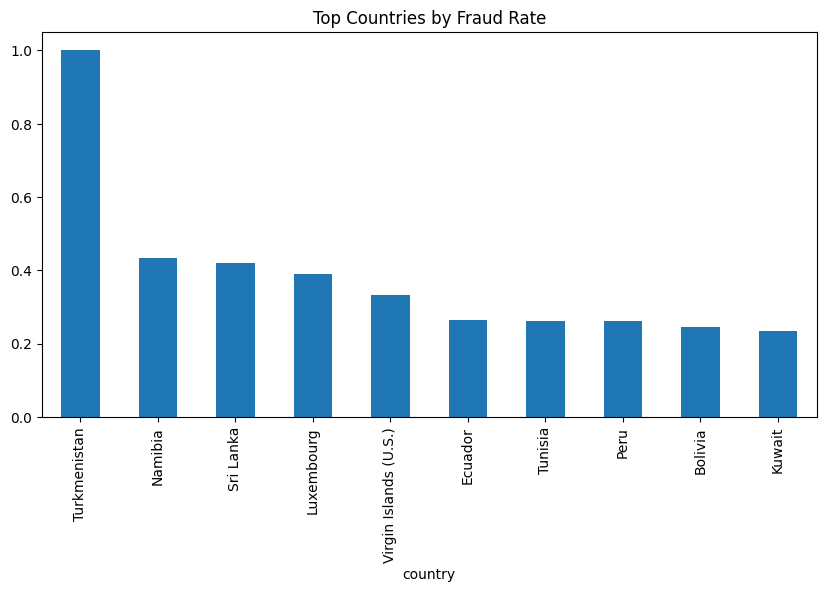

In [14]:
country_fraud.head(10).plot(
    kind="bar",
    figsize=(10,5),
    title="Top Countries by Fraud Rate"
)

### Observation

IP address enrichment successfully mapped transactions to geographic locations. Fraud rates vary substantially across countries, suggesting that geographic information may be a useful predictor for fraud detection. However, countries with very few transactions should be interpreted cautiously, as high fraud rates may result from small sample sizes.

In [15]:
fraud_geo["time_since_signup"] = (
    fraud_geo["purchase_time"]
    -
    fraud_geo["signup_time"]
).dt.total_seconds()

In [16]:
fraud_geo["time_since_signup"].describe()

count    1.291460e+05
mean     4.927250e+06
std      3.129629e+06
min      1.000000e+00
25%      2.180227e+06
50%      4.925322e+06
75%      7.643550e+06
max      1.036797e+07
Name: time_since_signup, dtype: float64

In [17]:
fraud_geo["hour_of_day"] = (
    fraud_geo["purchase_time"]
    .dt.hour
)

In [18]:
fraud_geo["hour_of_day"].value_counts().sort_index()

hour_of_day
0     5284
1     5308
2     5456
3     5565
4     5189
5     5266
6     5485
7     5311
8     5435
9     5524
10    5216
11    5389
12    5419
13    5365
14    5465
15    5432
16    5428
17    5517
18    5347
19    5385
20    5259
21    5313
22    5435
23    5353
Name: count, dtype: int64

In [19]:
fraud_geo["day_of_week"] = (
    fraud_geo["purchase_time"]
    .dt.dayofweek
)

In [20]:
fraud_geo["day_of_week"].value_counts().sort_index()

day_of_week
0    18565
1    18204
2    18159
3    18442
4    18374
5    18556
6    18846
Name: count, dtype: int64

<Axes: title={'center': 'Fraud Rate by Hour'}, xlabel='hour_of_day'>

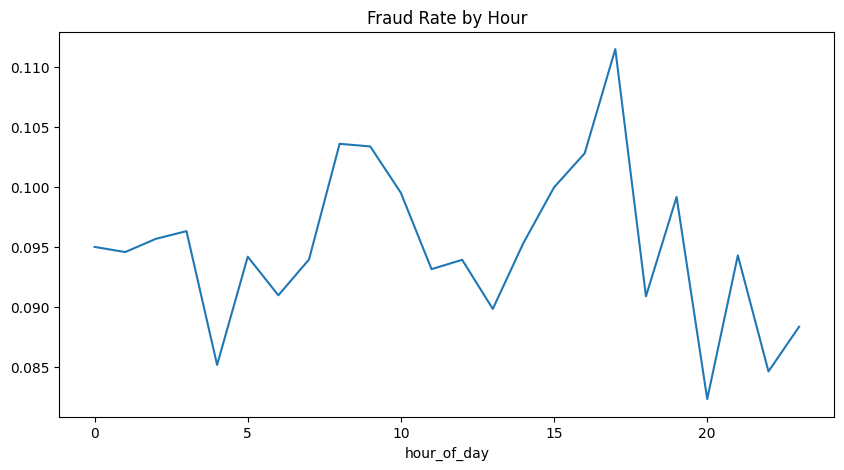

In [21]:
fraud_hour = (
    fraud_geo.groupby("hour_of_day")["class"]
    .mean()
)

fraud_hour.plot(
    kind="line",
    figsize=(10,5),
    title="Fraud Rate by Hour"
)

<Axes: title={'center': 'Fraud Rate by Day of Week'}, xlabel='day_of_week'>

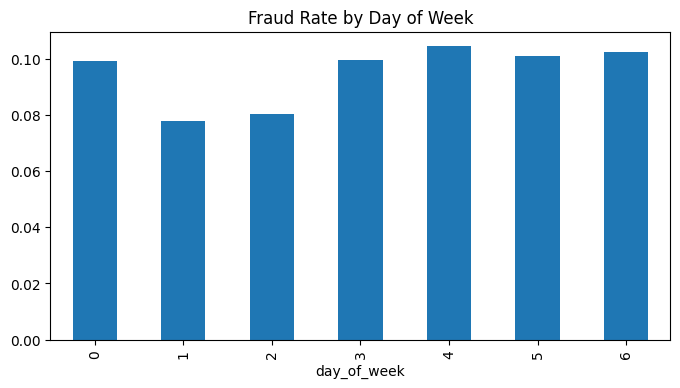

In [22]:
fraud_day = (
    fraud_geo.groupby("day_of_week")["class"]
    .mean()
)

fraud_day.plot(
    kind="bar",
    figsize=(8,4),
    title="Fraud Rate by Day of Week"
)

In [23]:
fraud_geo["user_transaction_count"] = (
    fraud_geo.groupby("user_id")
    ["user_id"]
    .transform("count")
)

In [24]:
fraud_geo["device_transaction_count"] = (
    fraud_geo.groupby("device_id")
    ["device_id"]
    .transform("count")
)

In [25]:
fraud_geo[
    [
        "time_since_signup",
        "hour_of_day",
        "day_of_week",
        "user_transaction_count",
        "device_transaction_count"
    ]
].head()

,time_since_signup,hour_of_day,day_of_week,user_transaction_count,device_transaction_count
634,3632215.0,3,6,1,1
635,1231637.0,20,2,1,1
636,1997534.0,23,5,1,2
637,7640897.0,16,5,1,1
638,10249579.0,4,1,1,1


In [26]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    "purchase_value",
    "age",
    "time_since_signup",
    "hour_of_day",
    "day_of_week",
    "user_transaction_count",
    "device_transaction_count"
]

fraud_geo[num_cols] = StandardScaler().fit_transform(
    fraud_geo[num_cols]
)

In [27]:
credit_df["Amount"] = StandardScaler().fit_transform(
    credit_df[["Amount"]]
)

In [28]:
X = fraud_geo.drop(columns=["class"])
y = fraud_geo["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [29]:
X_cc = credit_df.drop(columns=["Class"])
y_cc = credit_df["Class"]

X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X_cc,
    y_cc,
    test_size=0.2,
    stratify=y_cc,
    random_state=42
)

In [31]:
X_train.dtypes

user_id                              int64
signup_time                 datetime64[ns]
purchase_time               datetime64[ns]
purchase_value                     float64
device_id                           object
source                              object
browser                             object
sex                                 object
age                                float64
ip_address                           int64
lower_bound_ip_address             float64
upper_bound_ip_address             float64
country                             object
time_since_signup                  float64
hour_of_day                        float64
day_of_week                        float64
user_transaction_count             float64
device_transaction_count           float64
dtype: object

In [32]:
X = pd.get_dummies(
    X,
    columns=[
        "source",
        "browser",
        "sex",
        "country"
    ],
    drop_first=True
)

In [33]:
X.dtypes.unique()

array([dtype('int64'), dtype('<M8[ns]'), dtype('float64'), dtype('O'),
       dtype('bool')], dtype=object)

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [36]:
X.dtypes[X.dtypes == "datetime64[ns]"]

signup_time      datetime64[ns]
purchase_time    datetime64[ns]
dtype: object

In [37]:
X.dtypes[X.dtypes == "object"]

device_id    object
dtype: object

In [38]:
y = fraud_geo["class"]

X = fraud_geo.drop(columns=[
    "class",
    "signup_time",
    "purchase_time",
    "device_id",
    "user_id",
    "ip_address",
    "lower_bound_ip_address",
    "upper_bound_ip_address"
])

In [39]:
X = pd.get_dummies(
    X,
    columns=["source", "browser", "sex", "country"],
    drop_first=True
)

In [42]:
X.dtypes.unique()

array([dtype('float64'), dtype('bool')], dtype=object)

In [43]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(
    X_train,
    y_train
)

In [44]:
y_train.value_counts()
pd.Series(y_train_res).value_counts()

class
0    93502
1    93502
Name: count, dtype: int64

In [45]:
X_train_cc_res, y_train_cc_res = smote.fit_resample(
    X_train_cc,
    y_train_cc
)

In [46]:
fraud_geo.to_csv(
    "../data/processed/fraud_processed.csv",
    index=False
)

credit_df.to_csv(
    "../data/processed/creditcard_processed.csv",
    index=False
)

In [ ]:
X = fraud_geo.drop(columns=[
    "class",
    "signup_time",
    "purchase_time",
    "device_id",
    "user_id",
    "ip_address",
    "lower_bound_ip_address",
    "upper_bound_ip_address"
])

X = pd.get_dummies(
    X,
    columns=[
        "source",
        "browser",
        "sex",
        "country"
    ],
    drop_first=True
)

X = X.astype(float)

y = fraud_geo["class"]